# Regrid MLD from Treguier et al., 2023

This notebook documents the steps needed to regrid the MLD dataset to a nominal 2/3 deg MOM grid (tx2_3). 

Treguier, A. M., de Boyer Montégut, C., Bozec, A., Chassignet, E. P., Fox-Kemper, B., McC. Hogg, A., Iovino, D., Kiss, A. E., Le Sommer, J., Li, Y., Lin, P., Lique, C., Liu, H., Serazin, G., Sidorenko, D., Wang, Q., Xu, X., and Yeager, S.: The mixed-layer depth in the Ocean Model Intercomparison Project (OMIP): impact of resolving mesoscale eddies, Geosci. Model Dev., 16, 3849–3872, https://doi.org/10.5194/gmd-16-3849-2023, 2023.

In [1]:
%matplotlib inline

In [2]:
import xarray as xr
import xesmf
import numpy as np
import datetime
import numpy as np
import matplotlib.pyplot as plt

In [3]:
today = datetime.date.today().strftime("%y%m%d")
print(today)

260306


In [4]:
fname = '../../mesh/tx2_3v3_grid.nc'
grd_out = xr.open_dataset(fname).rename({'tlon': 'lon','tlat': 'lat', 'qlon': 'lon_b','qlat': 'lat_b',})
grd_out

<xarray.Dataset> Size: 42MB
Dimensions:  (ny: 480, nx: 540, nxp: 541, nyp: 481)
Dimensions without coordinates: ny, nx, nxp, nyp
Data variables: (12/20)
    lon      (ny, nx) float64 2MB ...
    lat      (ny, nx) float64 2MB ...
    ulon     (ny, nxp) float64 2MB ...
    ulat     (ny, nxp) float64 2MB ...
    vlon     (nyp, nx) float64 2MB ...
    vlat     (nyp, nx) float64 2MB ...
    ...       ...
    tarea    (ny, nx) float64 2MB ...
    tmask    (ny, nx) float64 2MB ...
    angle    (ny, nx) float64 2MB ...
    depth    (ny, nx) float64 2MB ...
    ar       (ny, nx) float64 2MB ...
    egs      (ny, nx) float64 2MB ...
Attributes:
    Description:  CESM MOM6 2/3 degree grid
    Author:       Frank, Fred, Gustavo (gmarques@ucar.edu)
    Created:      2026-03-05T14:49:28.971877
    type:         Glogal 2/3 degree grid file

In [5]:
infile = '/glade/campaign/cgd/oce/datasets/obs/mld/deBoyer_2023/mld_dr003_ref10m_v2023.nc'
ds_in = xr.open_dataset(infile, decode_times=False)

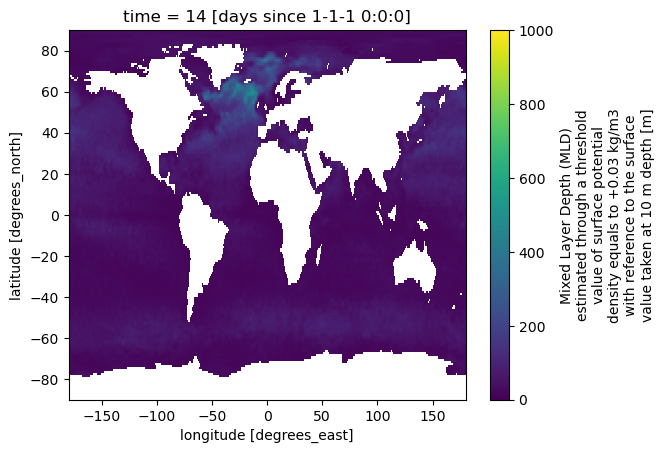

In [6]:
ds_in.mld_dr003[0,:].plot(vmin=0, vmax=1000);

In [7]:
# mask bad values
for t in range(len(ds_in.time)):
    tmp = np.nan_to_num(ds_in.mld_dr003[t,:].values, copy=True, posinf=0, neginf=0)
    ds_in['mld_dr003'][t,:,:] = tmp #.where(tmp == tmp).where(tmp>=0).where(tmp<1.0e6)

In [8]:
def regrid_mld(fld, ds_in, ds_out, method='bilinear'):

    regrid = xesmf.Regridder(
        ds_in,
        ds_out,
        method=method,
        periodic=True,
    )
    fld_out = regrid(ds_in[fld])
    return fld_out

In [9]:
ds_out = regrid_mld('mld_dr003', ds_in, grd_out).rename('mld').rename({'nx':'xh', 'ny':'yh'})

In [10]:
mask = grd_out.tmask.rename({'ny':'yh', 'nx':'xh'})

In [11]:
ds_out = ds_out.where(mask == 1)

## Visual inspection 
Make sure original and remapped plots look similar.

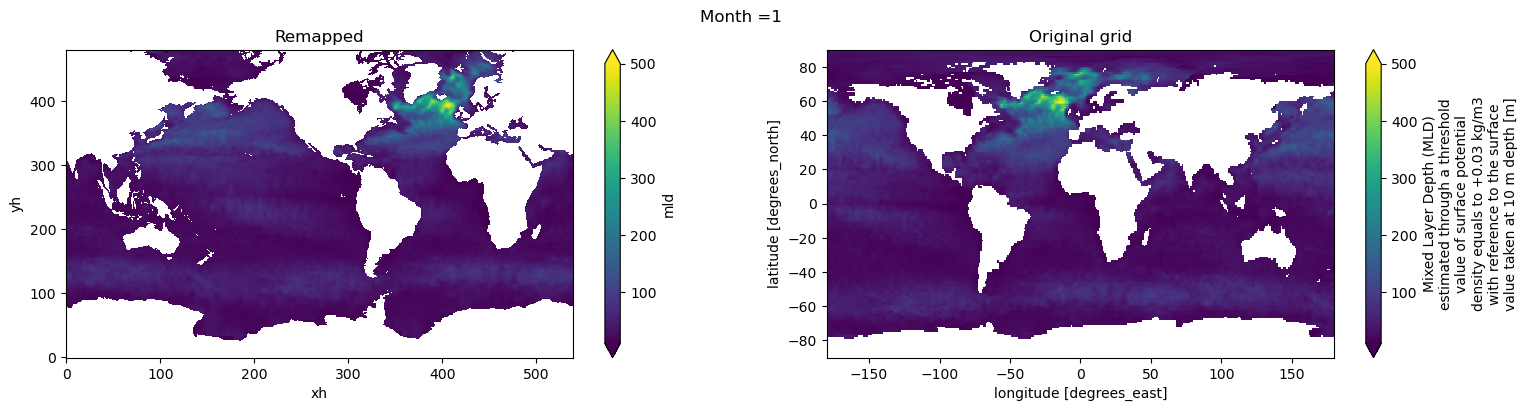

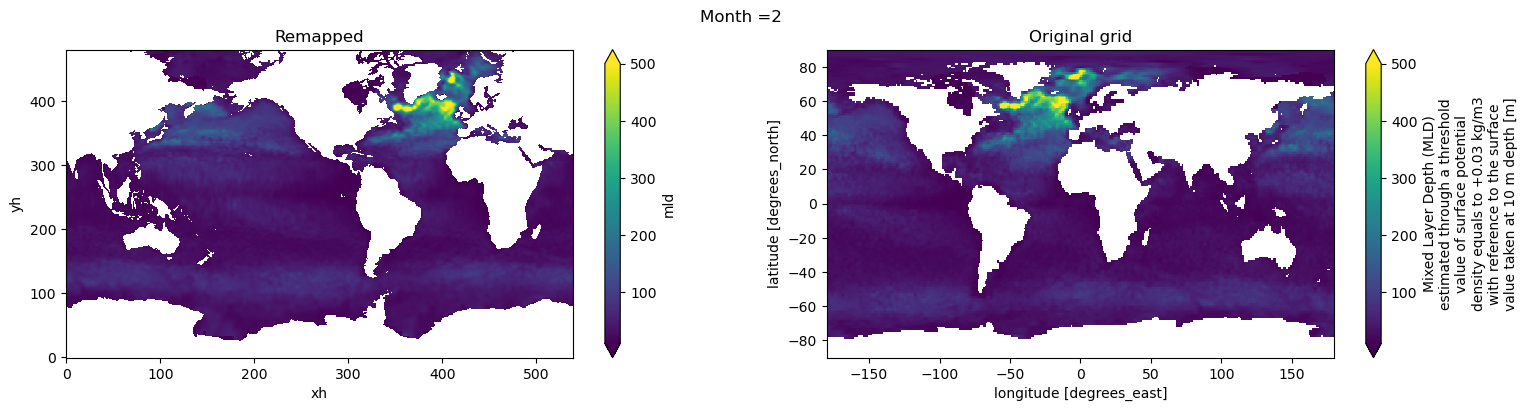

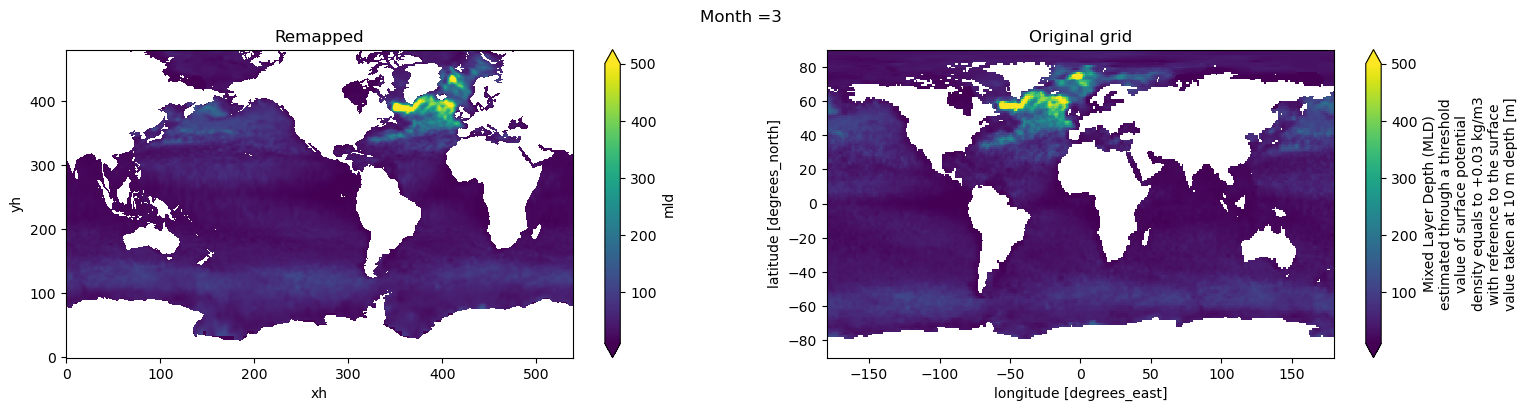

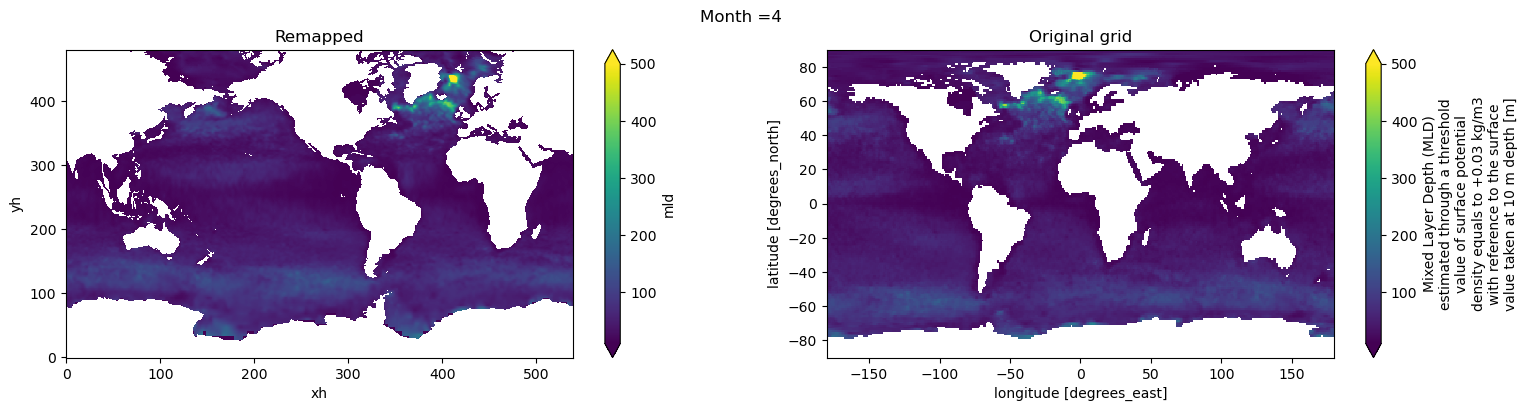

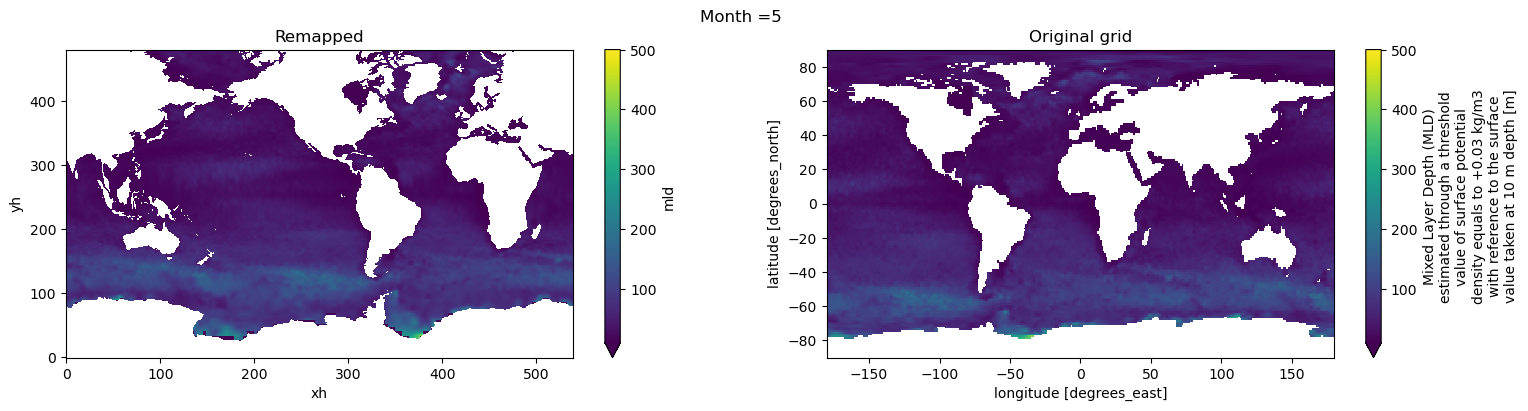

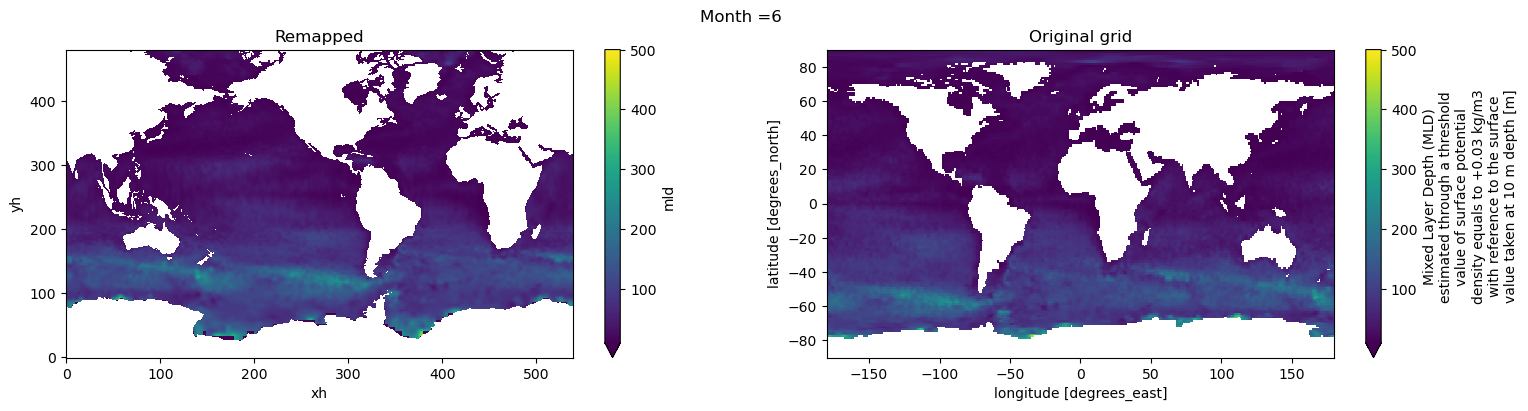

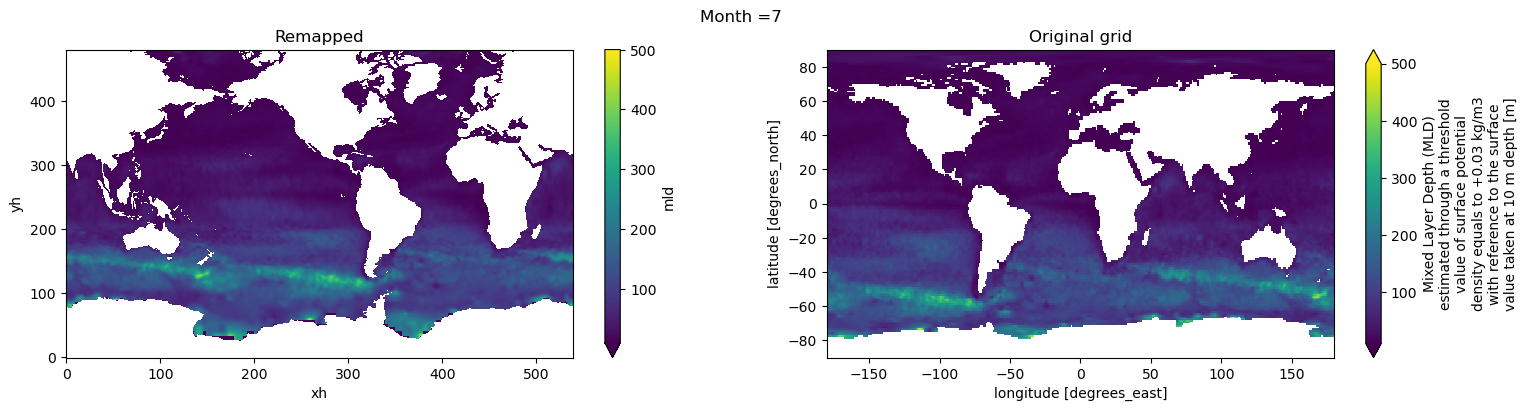

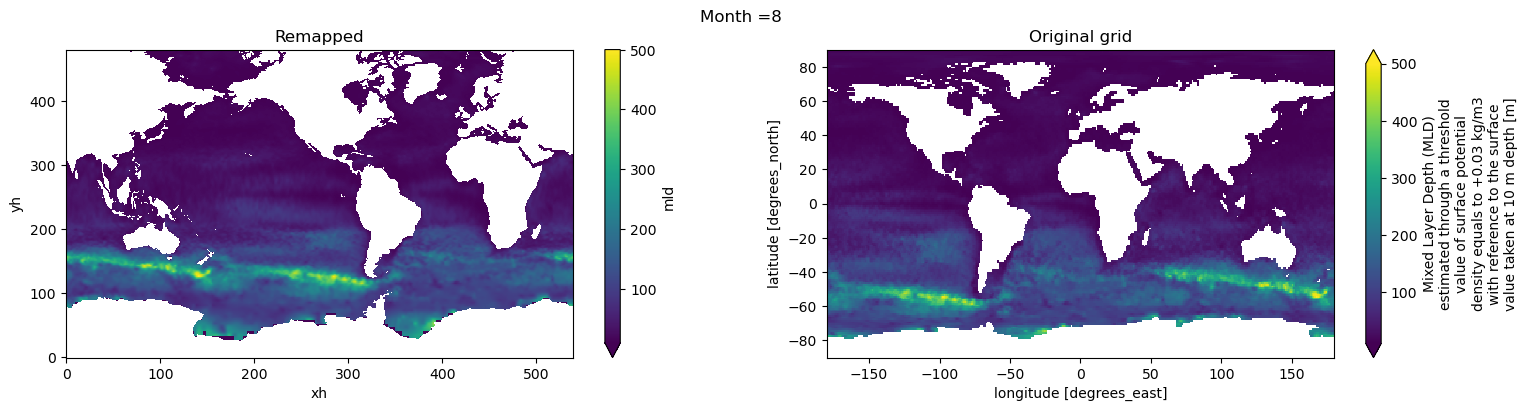

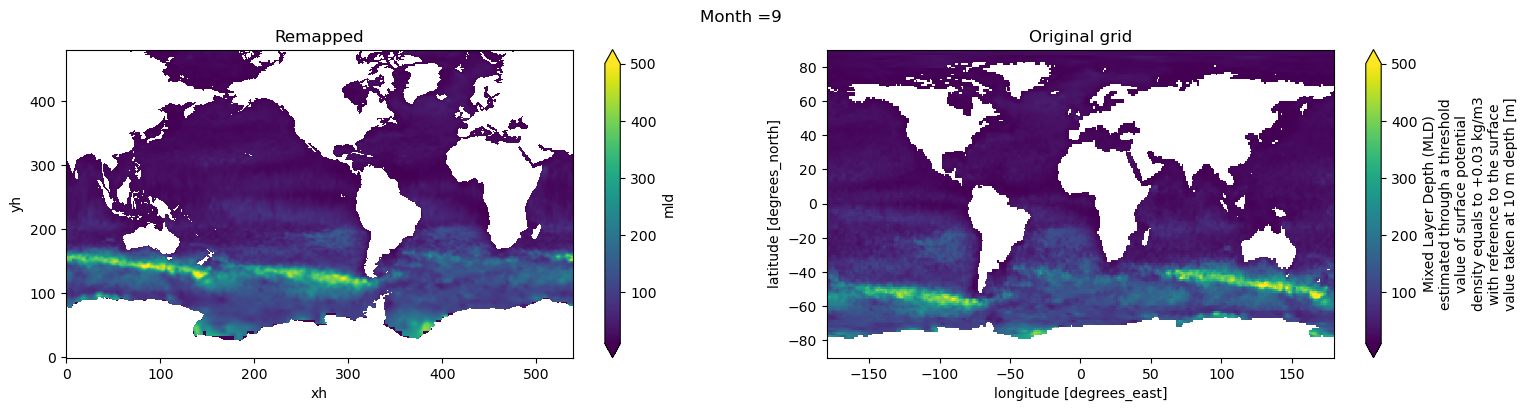

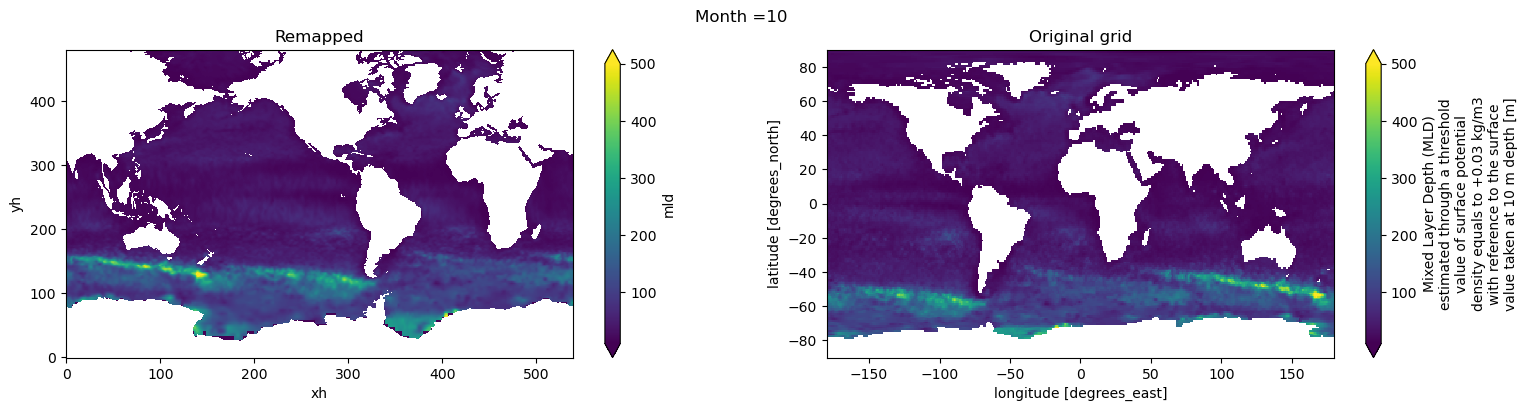

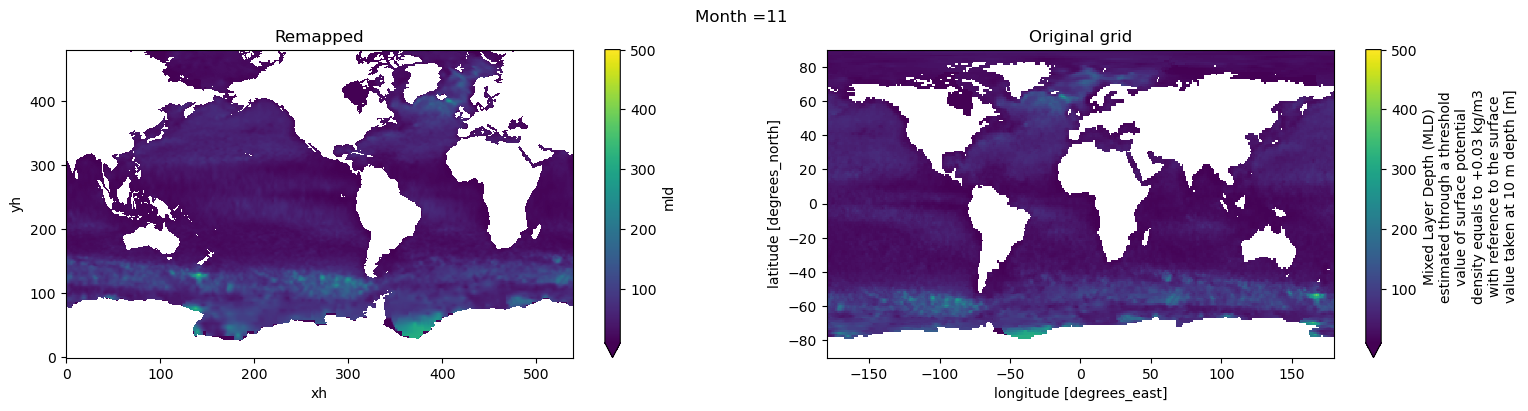

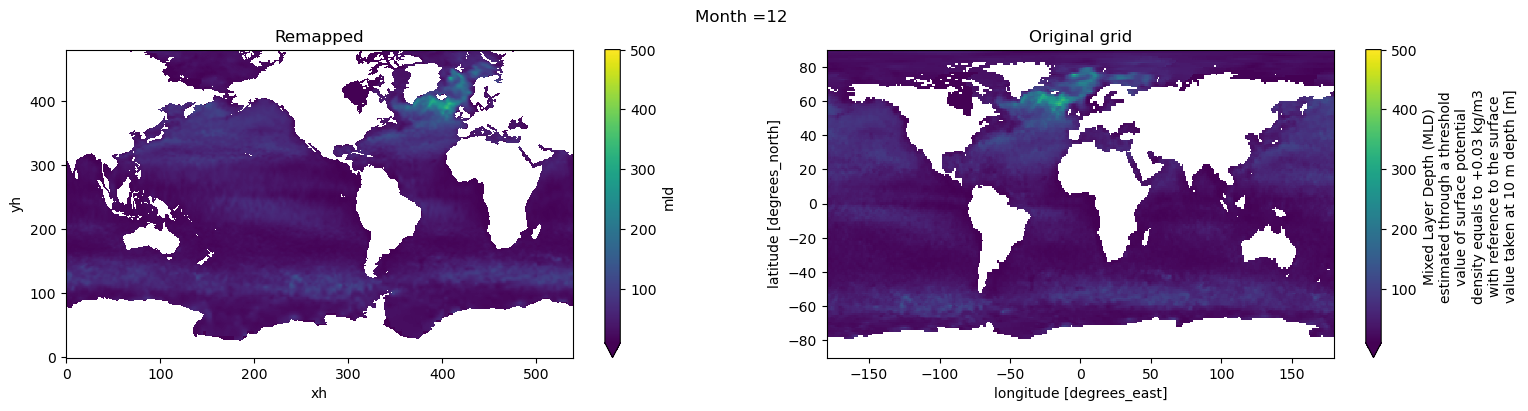

In [12]:
# visual inspection. Make sure original and remapped plots look similar
for t in range(len(ds_in.time)):
  fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18,4))
  ds_out[t,:,:].plot.pcolormesh(ax=axes[0], vmin=10,vmax=500)
  ds_in['mld_dr003'][t,:,:].where(ds_in.mask == 1).plot.pcolormesh(ax=axes[1], vmin=10,vmax=500)
  axes[0].set_title('Remapped')
  axes[1].set_title('Original grid')
  plt.suptitle('Month ='+ str(t+1))

In [13]:
ds_out.attrs['author'] = 'Gustavo Marques (gmarques@ucar.edu)'
ds_out.attrs['description'] = 'Mixed Layer Depth (MLD) estimated through a threshold value (increase) of surface potential density equals to 0.03 kg/m3 with reference to the surface value taken at 10 m depth (Treguier et al., 2023)'
ds_out.attrs['date'] = today
ds_out.attrs['infile'] = infile
ds_out.attrs['url'] = 'https://github.com/NCAR/tx2_3/mld/deBoyer2023/'
# save
fname = 'deBoyer23_MLD_remapped_to_tx2_3v3_{}.nc'.format(today)
ds_out.to_netcdf(fname)

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/dask/config.py:786: FutureWarning: Dask configuration key 'allowed-failures' has been deprecated; please use 'distributed.scheduler.allowed-failures' instead
  warnings.warn(
